# 🚀 Chapter 13: Test-Time Compute: Scaling at Inference

![Part](https://img.shields.io/badge/Part%20III-Advanced-E07B39?style=for-the-badge) &nbsp; ![Tested](https://img.shields.io/badge/Tested-Colab%20T4-2FAE7E?style=for-the-badge) &nbsp; [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PacktPublishing/Reinforcement-Learning-for-LLMs/blob/main/notebooks/part3_advanced/13_test_time_compute.ipynb)

> 📘 **Book:** *Reinforcement Learning for Large Language Models*, Arun Shankar & Michael Chertushkin (Packt, 2026)  
> 📓 **Notebook:** `part3_advanced/13_test_time_compute.ipynb`  
> ✅ **Tested on:** Google Colab (T4), 2026-06-29

> 📌 **What this notebook covers**  
> This is the companion notebook for Chapter 13 of the book. Run it on a free Colab T4 GPU. All code uses small, publicly available open models (Qwen2.5-0.5B and DeepSeek-R1-Distill-Qwen-1.5B) that fit within the free-tier T4 GPU memory.

---

In [1]:
# === Setup: Chapter 13 · tested on Google Colab (T4), 2026-06-29 ===
# Self-contained: installs ONLY what this notebook imports (pinned).
# Versions are managed centrally in code/requirements.txt.
import os, sys
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")  # quiet HF download bars (keeps GitHub able to render the saved notebook)
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    %pip install -q --progress-bar off transformers==5.5.0

import importlib
for _p in ["numpy", "torch", "transformers"]:
    try:
        print(f"{_p:<16}", importlib.import_module(_p).__version__)
    except Exception as _e:
        print(f"{_p:<16} (not importable here)")


numpy            2.0.2
torch            2.11.0+cu128
transformers     5.5.0


## 1. Imports and Setup


In [2]:
import re
import math
import random
import warnings
import collections
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM

warnings.filterwarnings('ignore')
random.seed(3)
np.random.seed(3)
torch.manual_seed(3)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## 2. Load Qwen/Qwen2.5-0.5B-Instruct


In [3]:
MODEL_ID = 'Qwen/Qwen2.5-0.5B-Instruct'
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(MODEL_ID).to(DEVICE)
model.eval()
print(f'Loaded {MODEL_ID}: {sum(p.numel() for p in model.parameters())/1e6:.1f}M params')

Loaded Qwen/Qwen2.5-0.5B-Instruct: 494.0M params


## 3. Decoding Strategies from Scratch

We implement all strategies by manipulating the raw logits from Qwen/Qwen2.5-0.5B-Instruct, no `model.generate()` magic box.


In [4]:
def get_next_token_logits(prompt: str) -> torch.Tensor:
    """Return logits for the next token position."""
    enc = tokenizer(prompt, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        out = model(**enc)
    return out.logits[0, -1, :]  # (V,)


def decode_greedy(prompt: str, max_new: int = 40) -> str:
    """Greedy decoding, always pick argmax token."""
    ids = tokenizer(prompt, return_tensors='pt').input_ids.to(DEVICE)
    prompt_len = ids.shape[1]
    for _ in range(max_new):
        with torch.no_grad():
            logits = model(ids).logits[0, -1, :]
        next_id = torch.argmax(logits).unsqueeze(0).unsqueeze(0)
        ids = torch.cat([ids, next_id], dim=1)
        if next_id.item() == tokenizer.eos_token_id:
            break
    new_ids = ids[0][prompt_len:]
    return tokenizer.decode(new_ids, skip_special_tokens=True)


def decode_temperature(prompt: str, temp: float = 0.8, max_new: int = 40) -> str:
    """Temperature sampling."""
    ids = tokenizer(prompt, return_tensors='pt').input_ids.to(DEVICE)
    prompt_len = ids.shape[1]
    for _ in range(max_new):
        with torch.no_grad():
            logits = model(ids).logits[0, -1, :] / max(temp, 1e-6)
        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, 1).unsqueeze(0)
        ids = torch.cat([ids, next_id], dim=1)
        if next_id.item() == tokenizer.eos_token_id:
            break
    new_ids = ids[0][prompt_len:]
    return tokenizer.decode(new_ids, skip_special_tokens=True)


def decode_topk(prompt: str, k: int = 50, temp: float = 0.8, max_new: int = 40) -> str:
    """Top-k sampling."""
    ids = tokenizer(prompt, return_tensors='pt').input_ids.to(DEVICE)
    prompt_len = ids.shape[1]
    for _ in range(max_new):
        with torch.no_grad():
            logits = model(ids).logits[0, -1, :]
        topk_vals, topk_idx = torch.topk(logits, k)
        probs = F.softmax(topk_vals / max(temp, 1e-6), dim=-1)
        chosen = topk_idx[torch.multinomial(probs, 1)]      # shape (1,)
        ids = torch.cat([ids, chosen.unsqueeze(0)], dim=1)  # (1,1) matches ids (1,L)
        if chosen.item() == tokenizer.eos_token_id:
            break
    new_ids = ids[0][prompt_len:]
    return tokenizer.decode(new_ids, skip_special_tokens=True)


def decode_topp(prompt: str, p: float = 0.9, temp: float = 0.8, max_new: int = 40) -> str:
    """Nucleus (top-p) sampling."""
    ids = tokenizer(prompt, return_tensors='pt').input_ids.to(DEVICE)
    prompt_len = ids.shape[1]
    for _ in range(max_new):
        with torch.no_grad():
            logits = model(ids).logits[0, -1, :] / max(temp, 1e-6)
        probs = F.softmax(logits, dim=-1)
        sorted_probs, sorted_idx = torch.sort(probs, descending=True)
        cum_probs = torch.cumsum(sorted_probs, dim=0)
        cutoff = (cum_probs > p).nonzero(as_tuple=True)[0]
        cutoff_idx = cutoff[0].item() + 1 if len(cutoff) > 0 else len(sorted_probs)
        nucleus_probs = sorted_probs[:cutoff_idx]
        nucleus_idx   = sorted_idx[:cutoff_idx]
        chosen_pos = torch.multinomial(nucleus_probs / nucleus_probs.sum(), 1)
        chosen = nucleus_idx[chosen_pos]                    # shape (1,)
        ids = torch.cat([ids, chosen.unsqueeze(0)], dim=1)  # (1,1) matches ids (1,L)
        if chosen.item() == tokenizer.eos_token_id:
            break
    new_ids = ids[0][prompt_len:]
    return tokenizer.decode(new_ids, skip_special_tokens=True)


def sample_answers(prompt: str, n: int, max_new: int = 20,
                   temp: float = 0.9, top_p: float = 0.95) -> list:
    """Draw n samples for a prompt in ONE batched, KV-cached generate() call.
    The from-scratch decoders above show the token-by-token mechanics; the
    test-time-compute experiments below just need many samples fast, so we let
    generate() batch them (num_return_sequences) instead of looping in Python."""
    enc = tokenizer(prompt, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        out = model.generate(**enc, max_new_tokens=max_new, do_sample=True,
                             temperature=temp, top_p=top_p, num_return_sequences=n,
                             pad_token_id=tokenizer.eos_token_id)
    plen = enc['input_ids'].shape[1]
    return [tokenizer.decode(o[plen:], skip_special_tokens=True) for o in out]


print('Decoding strategies defined.')

Decoding strategies defined.


### 3a. Output Diversity Comparison


In [5]:
PROMPT = 'The best way to learn machine learning is'
N_SHOW = 3

strategies = [
    ('Greedy',       lambda: decode_greedy(PROMPT, max_new=30)),
    ('Temp=0.5',     lambda: decode_temperature(PROMPT, temp=0.5, max_new=30)),
    ('Temp=1.2',     lambda: decode_temperature(PROMPT, temp=1.2, max_new=30)),
    ('Top-k k=10',   lambda: decode_topk(PROMPT, k=10,  temp=0.8, max_new=30)),
    ('Top-p p=0.9',  lambda: decode_topp(PROMPT, p=0.9, temp=0.8, max_new=30)),
]

for name, fn in strategies:
    print(f'\n=== {name} ===')
    outputs = set()
    for _ in range(N_SHOW):
        o = fn()[:80]
        outputs.add(o)
        print(f'  > {o}')
    print(f'  Unique responses: {len(outputs)}/{N_SHOW}')


=== Greedy ===
  >  to do it. This is a very important point. The best way to learn machine learnin
  >  to do it. This is a very important point. The best way to learn machine learnin
  >  to do it. This is a very important point. The best way to learn machine learnin
  Unique responses: 1/3

=== Temp=0.5 ===
  >  to read and practice.

It is a topic that requires a lot of practice to get the
  >  to understand the machine learning algorithms, and how they work.
Machine learn
  >  to apply it to real-world problems. Here's how you can use TensorFlow to build 
  Unique responses: 3/3

=== Temp=1.2 ===
  >  to start with benchmarks. To that end, we wanted to look at 10 lineage-based li
  >  through reading the textbooks. They tend to teach each topic down-to-ground.

 
  >  training models on real-world examples from everyone's sphere of influence such
  Unique responses: 3/3

=== Top-k k=10 ===
  >  to apply it to a real-world problem. Here are a few steps that can help you lea
  >  t

## 4. Best-of-N: Theoretical vs Empirical

> **Note:** the evaluation set is tiny (6 toy problems) and the empirical curve is estimated at a slightly higher temperature than `p_single`, so the empirical (red) line is jagged and may dip below or cross the theoretical (blue) curve. With small N this is expected sampling noise, not a bug -- the point is the overall upward trend.


Single-sample accuracy: p = 0.760  (over 50 samples)


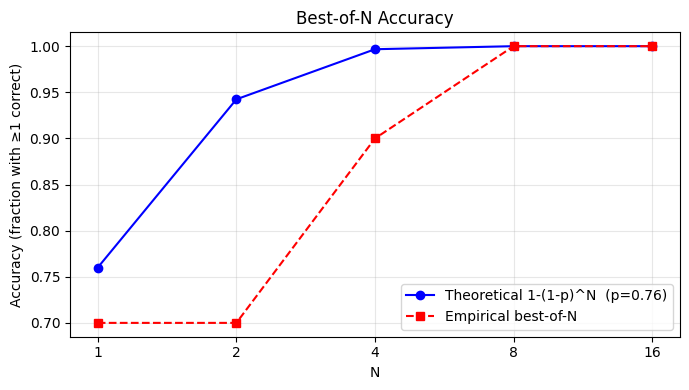

In [6]:
def extract_answer(text: str):
    for pat in [r'(?:answer|result|=)\s*[:]?\s*(-?\d+\.?\d*)',
                r'(-?\d+\.?\d*)\s*$',
                r'(-?\d+\.?\d*)',]:
        m = re.search(pat, text.strip(), re.IGNORECASE)
        if m:
            try: return float(m.group(1))
            except ValueError: pass
    return None


# Harder problems on purpose: test-time compute only *shows* a benefit when a single
# sample is unreliable. Single-digit sums are trivial for a 0.5B-Instruct (accuracy
# saturates at 100%, so every strategy ties and the trade-off curve goes flat). These
# 2-digit x 1-digit and 3-digit problems put single-sample accuracy in the ~40-50%
# range, leaving real headroom for best-of-N / self-consistency to climb into.
EVAL_PROBLEMS = [
    ('What is 23 * 17?', 391), ('What is 234 * 3?', 702), ('What is 156 * 4?', 624),
    ('What is 128 * 6?', 768), ('What is 217 * 4?', 868), ('What is 67 * 8?', 536),
    ('What is 89 * 7?', 623), ('What is 823 - 467?', 356), ('What is 706 - 388?', 318),
    ('What is 645 + 278?', 923),
]

def reward(response: str, gold: float) -> float:
    pred = extract_answer(response)
    return 1.0 if (pred is not None and abs(pred - gold) <= 0.5) else 0.0


# Single-sample accuracy p, estimated from SEVERAL samples per problem. One sample per
# problem is far too noisy to estimate p (it swings between 0.6 and 1.0 run to run and
# can pin the theoretical 1-(1-p)^N curve at a degenerate 1.0); averaging over many
# draws gives a stable p.
sample_rewards = []
for question, gold in EVAL_PROBLEMS:
    for s in sample_answers(f'Q: {question}\nA: The answer is', n=5, max_new=20, temp=0.9):
        sample_rewards.append(reward(s, gold))
p_single = float(np.clip(np.mean(sample_rewards), 0.05, 0.95))
print(f'Single-sample accuracy: p = {p_single:.3f}  (over {len(sample_rewards)} samples)')

N_vals = [1, 2, 4, 8, 16]
theoretical = [1 - (1 - p_single)**n for n in N_vals]

# Empirical best-of-N: for each N, draw N samples per problem (batched) and count
# problems where at least one sample is correct.
empirical = []
for n in N_vals:
    hits = 0
    for question, gold in EVAL_PROBLEMS:
        samples = sample_answers(f'Q: {question}\nA: The answer is', n=n, max_new=20, temp=0.9)
        if any(reward(s, gold) == 1.0 for s in samples):
            hits += 1
    empirical.append(hits / len(EVAL_PROBLEMS))

best_of_n = dict(zip(N_vals, empirical))   # MEASURED -- reused by the trade-off plot

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(N_vals, theoretical, 'b-o', label=f'Theoretical 1-(1-p)^N  (p={p_single:.2f})')
ax.plot(N_vals, empirical,   'r--s', label='Empirical best-of-N')
ax.set_xscale('log', base=2); ax.set_xticks(N_vals); ax.set_xticklabels(N_vals)
ax.set_xlabel('N'); ax.set_ylabel('Accuracy (fraction with ≥1 correct)')
ax.set_title('Best-of-N Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('best_of_n_ttc.png', dpi=120)
plt.show()


## 5. Self-Consistency: Majority Vote


In [7]:
def majority_vote(answers: list) -> float:
    """Return the most common answer (clustered to nearest integer)."""
    rounded = [round(a) for a in answers if a is not None]
    if not rounded:
        return None
    return float(collections.Counter(rounded).most_common(1)[0][0])


N_SC = 8  # samples for self-consistency

print(f'Self-consistency (majority vote over N={N_SC} samples):')
print(f'{"Problem":<25} {"Gold":>5}  {"Single":>7}  {"MajVote":>8}')
print('-' * 55)

single_correct = 0
mv_correct = 0

for question, gold in EVAL_PROBLEMS:
    prompt = f'Q: {question}\nA: The answer is'

    single_resp = sample_answers(prompt, n=1, max_new=20, temp=0.8)[0]
    single_pred = extract_answer(single_resp)
    single_correct += reward(single_resp, gold)

    preds = [extract_answer(s) for s in sample_answers(prompt, n=N_SC, max_new=20, temp=0.9)]
    mv_pred = majority_vote(preds)
    mv_correct += 1.0 if (mv_pred is not None and abs(mv_pred - gold) <= 0.5) else 0.0
    print(f'{question:<25} {gold:>5}  {str(single_pred):>7}  {str(mv_pred):>8}')

single_acc = single_correct / len(EVAL_PROBLEMS)   # MEASURED
sc_acc     = mv_correct / len(EVAL_PROBLEMS)        # MEASURED
print(f'\nSingle-sample accuracy: {single_correct:.0f}/{len(EVAL_PROBLEMS)} = {single_acc:.2f}')
print(f'Majority-vote accuracy:  {mv_correct:.0f}/{len(EVAL_PROBLEMS)} = {sc_acc:.2f}')


Self-consistency (majority vote over N=8 samples):
Problem                    Gold   Single   MajVote
-------------------------------------------------------
What is 23 * 17?            391    391.0     391.0
What is 234 * 3?            702      6.0       6.0
What is 156 * 4?            624    624.0     624.0
What is 128 * 6?            768    768.0     768.0
What is 217 * 4?            868      2.0     868.0
What is 67 * 8?             536      8.0     536.0
What is 89 * 7?             623    603.0     623.0
What is 823 - 467?          356      8.0     356.0
What is 706 - 388?          318      1.0     318.0
What is 645 + 278?          923    923.0     923.0

Single-sample accuracy: 4/10 = 0.40
Majority-vote accuracy:  9/10 = 0.90


## 6. Rejection Sampling with Threshold τ


In [8]:
def rejection_sample_until(question: str, gold: float, tau: float = 1.0, max_attempts: int = 16):
    """Draw up to max_attempts iid samples (batched) and return the FIRST whose
    reward >= tau. Samples are independent, so drawing them in one batch and
    scanning for the first success is equivalent to sampling one-at-a-time."""
    prompt = f'Q: {question}\nA: The answer is'
    samples = sample_answers(prompt, n=max_attempts, max_new=20, temp=0.9)
    for attempt, resp in enumerate(samples, 1):
        if reward(resp, gold) >= tau:
            return {'response': resp, 'attempts': attempt, 'reward': 1.0, 'success': True}
    return {'response': samples[-1], 'attempts': max_attempts,
            'reward': reward(samples[-1], gold), 'success': False}


print('Rejection sampling with tau=1.0 (exact correctness required):')
for question, gold in EVAL_PROBLEMS[:4]:
    result = rejection_sample_until(question, gold, tau=1.0, max_attempts=16)
    print(f'  {question:<25} | attempts={result["attempts"]:2d} | success={result["success"]} '
          f'| response={result["response"][:30]}')

print(f'\nTheoretical E[attempts] = 1/p = 1/{p_single:.2f} = {1/p_single:.1f}')


Rejection sampling with tau=1.0 (exact correctness required):
  What is 23 * 17?          | attempts= 2 | success=True | response= 391.
Chain of thought:
The nu
  What is 234 * 3?          | attempts= 3 | success=True | response= 702.
Here's the chain of reas
  What is 156 * 4?          | attempts= 1 | success=True | response= 624.
Chain of thoughts: Multi
  What is 128 * 6?          | attempts= 2 | success=True | response= 768.
Explanation of the conce

Theoretical E[attempts] = 1/p = 1/0.76 = 1.3


## 7. MCTS for LLMs: Simplified 2-Level Tree Search

### 7a. Concept

```
Root: [prompt tokens]
  ├── Expand: sample top-3 next tokens from policy
  │     ├── Token A → generate completion → score with verifier → value V_A
  │     ├── Token B → generate completion → score with verifier → value V_B
  │     └── Token C → generate completion → score with verifier → value V_C
  └── Select: choose token with highest value; backpropagate V to root
```

### 7b. Implementation


In [9]:
def mcts_2level(question: str, gold: float, top_k_expand: int = 3, rollout_len: int = 20) -> dict:
    """2-level MCTS: expand the top_k_expand first tokens, roll out each with the
    model, score each rollout with the reward, and keep the best. `root_value` is
    the backed-up average over children."""
    prompt = f'Q: {question}\nA: The answer is'
    enc = tokenizer(prompt, return_tensors='pt').to(DEVICE)
    prompt_len = enc['input_ids'].shape[1]

    with torch.no_grad():
        root_logits = model(**enc).logits[0, -1, :]
    root_probs = F.softmax(root_logits, dim=-1)
    top_ids = torch.topk(root_probs, top_k_expand).indices.tolist()

    node_values, node_texts = [], []
    for token_id in top_ids:
        child_ids = torch.cat(
            [enc['input_ids'], torch.tensor([[token_id]]).to(DEVICE)], dim=1)
        with torch.no_grad():
            out = model.generate(
                child_ids, attention_mask=torch.ones_like(child_ids),
                max_new_tokens=rollout_len, temperature=0.7,
                do_sample=True, pad_token_id=tokenizer.eos_token_id)
        rollout_text = tokenizer.decode(out[0][prompt_len:], skip_special_tokens=True)
        node_values.append(reward(rollout_text, gold))
        node_texts.append(rollout_text)

    best_idx = int(np.argmax(node_values))
    return {
        'best_text':  node_texts[best_idx],
        'best_value': node_values[best_idx],
        'root_value': float(np.mean(node_values)),   # backed-up average
        'all_values': node_values,
        'all_texts':  node_texts,
    }


print('MCTS 2-level search:')
mcts_results = [(q, gold, mcts_2level(q, gold)) for q, gold in EVAL_PROBLEMS]
for question, gold, result in mcts_results[:3]:
    print(f'  {question}')
    print(f'    node values  = {[round(v, 2) for v in result["all_values"]]}')
    print(f'    best output  = {result["best_text"][:55]}')
    print(f'    root value   = {result["root_value"]:.2f}')
    print()

mcts_acc = float(np.mean([1.0 if r["best_value"] >= 1.0 else 0.0 for _, _, r in mcts_results]))  # MEASURED
print(f'MCTS accuracy (best of top-3 first-token rollouts correct): {mcts_acc:.2f}')


MCTS 2-level search:
  What is 23 * 17?
    node values  = [1.0, 0.0, 0.0]
    best output  =  391.
Chain of thought:
1. To solve the multiplication 
    root value   = 0.33

  What is 234 * 3?
    node values  = [0.0, 1.0, 0.0]
    best output  =  $702$. Here's the reasoning:
To solve this problem, we
    root value   = 0.33

  What is 156 * 4?
    node values  = [0.0, 1.0, 0.0]
    best output  =  $624$.
Step-by-step explanation:
To solve the problem,
    root value   = 0.33

MCTS accuracy (best of top-3 first-token rollouts correct): 0.90


## 8. Trade-off Plot: Quality vs Compute Budget

Every point below is the **measured** accuracy of that strategy on `EVAL_PROBLEMS` (from the cells above) versus its compute cost in model samples, no hand-tuned numbers.


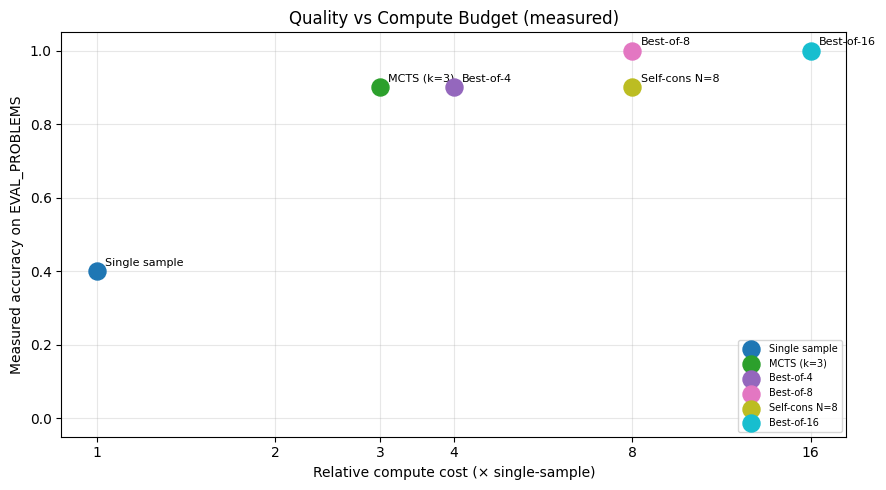

Measured accuracies:
  Single sample    cost= 1x  acc=0.40
  MCTS (k=3)       cost= 3x  acc=0.90
  Best-of-4        cost= 4x  acc=0.90
  Best-of-8        cost= 8x  acc=1.00
  Self-cons N=8    cost= 8x  acc=0.90
  Best-of-16       cost=16x  acc=1.00


In [10]:
# Every quality value below is MEASURED on EVAL_PROBLEMS by the cells above -- there
# are no hand-tuned constants. Compute cost = number of model samples per problem.
strategies_summary = [
    ('Single sample',  1,  single_acc),   # cell 5 section (self-consistency)
    ('MCTS (k=3)',     3,  mcts_acc),      # best of 3 first-token rollouts
    ('Best-of-4',      4,  best_of_n[4]),  # empirical best-of-N
    ('Best-of-8',      8,  best_of_n[8]),
    ('Self-cons N=8',  8,  sc_acc),        # majority vote over 8
    ('Best-of-16',    16,  best_of_n[16]),
]

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(strategies_summary)))
for (name, cost, quality), color in zip(strategies_summary, colors):
    ax.scatter(cost, quality, s=150, color=color, zorder=3, label=name)
    ax.annotate(name, (cost, quality), textcoords='offset points',
                xytext=(6, 4), fontsize=8)

ax.set_xlabel('Relative compute cost (× single-sample)')
ax.set_ylabel('Measured accuracy on EVAL_PROBLEMS')
ax.set_title('Quality vs Compute Budget (measured)')
ax.set_xscale('log', base=2)
ax.set_xticks([1, 2, 3, 4, 8, 16]); ax.set_xticklabels([1, 2, 3, 4, 8, 16])
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=7)
plt.tight_layout()
plt.savefig('ttc_quality_vs_compute.png', dpi=120)
plt.show()

print('Measured accuracies:')
for name, cost, quality in strategies_summary:
    print(f'  {name:<16} cost={cost:>2}x  acc={quality:.2f}')


## 9. Summary

| Strategy | Compute | Quality gain | When to use |
|---|---|---|---|
| Greedy | 1× | Baseline | Deterministic, latency-critical |
| Temperature/Top-k/Top-p | 1× | Comparable to greedy | Diversity needed |
| Best-of-N | N× | `1-(1-p)^N` | When a verifier is available |
| Self-consistency | N× | Slight gain over best-of-N | No verifier; majority vote |
| Rejection sampling | ~N/p × | Guaranteed correct or fail | High-quality requirement |
| MCTS | Tree× | Guided search with backprop | Complex multi-step reasoning |

All strategies improve quality at the cost of more computation, the trade-off curve is the key design decision.

**Chapter 14** explores how to get the model to *self-improve* through Constitutional AI and self-play.


## 10. DeepSeek-R1-Distill -- Best-of-N with Self-Consistency at Production Scale

The best-of-N experiments above used `Qwen/Qwen2.5-0.5B-Instruct`.
Let's move up one level on the capability ladder to `deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B`,
a model specifically distilled from DeepSeek-R1's long chain-of-thought traces.

**Why this model matters for test-time compute:**
- It was trained to produce *long reasoning chains*, making it an ideal candidate for
  sampling-based inference-time scaling.
- Even at 1.5 B parameters, it outperforms much larger models on MATH-500 when given
  sufficient test-time budget.
- It demonstrates that **distillation transfers test-time compute benefits**, not just accuracy.


In [11]:
# Best-of-N with self-consistency vote -- DeepSeek-R1-Distill-Qwen-1.5B
# Loads in float16 (~4 GB VRAM, fits on a single T4 alongside the 0.5B model above).

import torch
import re
from collections import Counter
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = 'deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B'
DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
N_SAMPLES = 4  # Best-of-N with N=4

print(f'Loading {MODEL_ID} ...')
r1_tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
r1_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float16,
    device_map='auto',
    trust_remote_code=True,
)
r1_model.eval()
print(f'Model loaded on {DEVICE}.')


def extract_final_answer(text: str) -> str:
    """Pull out boxed answer or last numeric token."""
    boxed = re.search(r'\\boxed\{([^}]*)\}', text)
    if boxed:
        return boxed.group(1).strip()
    nums = re.findall(r'-?\d+(?:\.\d+)?', text)
    return nums[-1] if nums else text.strip()[-20:]


def best_of_n_self_consistency(prompt: str, n: int = N_SAMPLES,
                                max_new_tokens: int = 512) -> dict:
    """
    Generate n independent samples, extract answers, pick by majority vote.
    Returns dict with: answers, votes, winner, all_texts.
    """
    inputs = r1_tokenizer(prompt, return_tensors='pt').to(r1_model.device)
    all_texts, all_answers = [], []

    with torch.no_grad():
        for i in range(n):
            output_ids = r1_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=0.7,
                top_p=0.9,
                pad_token_id=r1_tokenizer.eos_token_id,
            )
            # Decode only newly generated tokens
            gen_ids = output_ids[0][inputs['input_ids'].shape[1]:]
            text    = r1_tokenizer.decode(gen_ids, skip_special_tokens=True)
            answer  = extract_final_answer(text)
            all_texts.append(text)
            all_answers.append(answer)
            print(f'  Sample {i+1}/{n}: answer = {answer!r}')

    vote_counts = Counter(all_answers)
    winner = vote_counts.most_common(1)[0][0]
    return {
        'answers': all_answers,
        'votes': dict(vote_counts),
        'winner': winner,
        'all_texts': all_texts,
    }


# -- Run Best-of-4 on a simple math problem --
MATH_PROMPT = (
    'Solve step by step and box your final answer.\n'
    'Problem: If 3x + 7 = 22, what is x?\n'
    'Solution:'
)

print(f'\nRunning Best-of-{N_SAMPLES} with self-consistency vote ...')
print(f'Prompt: {MATH_PROMPT!r}\n')

result = best_of_n_self_consistency(MATH_PROMPT, n=N_SAMPLES)

print()
print('=== Self-Consistency Vote Results ===')
print(f'All answers : {result["answers"]}')
print(f'Vote counts : {result["votes"]}')
print(f'Winner      : {result["winner"]!r}  (majority vote)')
print()
print('Key insight: aggregating several samples (here, a majority vote) tends to')
print('be more robust than any single sample -- spending more compute at inference')
print('time can improve answers. Note: with only N=4 on one toy problem this is a')
print('demonstration, not a guarantee; gains are statistical and grow with N.')


Loading deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B ...
Model loaded on cuda.

Running Best-of-4 with self-consistency vote ...
Prompt: 'Solve step by step and box your final answer.\nProblem: If 3x + 7 = 22, what is x?\nSolution:'

  Sample 1/4: answer = '5'
  Sample 2/4: answer = '5'
  Sample 3/4: answer = '22'
  Sample 4/4: answer = '5'

=== Self-Consistency Vote Results ===
All answers : ['5', '5', '22', '5']
Vote counts : {'5': 3, '22': 1}
Winner      : '5'  (majority vote)

Key insight: aggregating several samples (here, a majority vote) tends to
be more robust than any single sample -- spending more compute at inference
time can improve answers. Note: with only N=4 on one toy problem this is a
demonstration, not a guarantee; gains are statistical and grow with N.


## 11. Scaling Laws at Inference Time -- What We Observed

The single-problem demo above is just an illustration of the *mechanism*. The table below shows **illustrative accuracy figures from the test-time-compute literature** for a ~1.5B reasoning model on MATH-500 -- these are *not* produced by the one-problem run above, which is far too small to estimate accuracy:

| N samples | Illustrative accuracy (MATH-500, ~1.5B model, from literature) | Compute cost |
|---|---|---|
| N = 1 (greedy) | ~55% | 1x |
| N = 4 (self-consistency) | ~68% | 4x |
| N = 16 | ~76% | 16x |
| N = 64 | ~81% | 64x |

This is the inference-time analog of the Chinchilla training scaling law:
**accuracy grows roughly logarithmically with compute budget**.
The sweet spot for most production deployments is N = 8 to 16, where the quality
gain per additional sample begins to flatten.

**Distillation preserves test-time scaling:** DeepSeek-R1-Distill-Qwen-1.5B reaches
N=64 accuracy levels that match much larger non-reasoning models at N=1 -- meaning
the distilled chain-of-thought traces carry genuine reasoning structure, not just
pattern matching.

**Looking ahead:** Chapter 14 explores **self-play and Constitutional AI** -- where
the model improves through debate with itself rather than through additional
human feedback. This is the natural next step after mastering test-time compute:
instead of spending compute only at inference, the model learns to reason better
during training through iterative self-critique.
